# 14 - pushing many anchors: the shared push budget

Notebook 02 had Wax push a single coin. But a Coinshot rarely pushes just
one thing: they fly on a tripod of coins, spray coins at a target, push a
bullet aside while shoving off a doorframe. This notebook asks what the
push does when it has several metal targets at once.

Canon research first (Coppermind and 17th Shard, checked 2026-06-12). What
the books and Word of Brandon are clear on: push strength is roughly
proportional to the Allomancer's weight; relative mass decides who moves
(lighter flies, heavier or well-anchored throws you); if the anchor holds,
the force reflects back onto the Allomancer; and a tripod of anchors is the
canonical way to fly stably. What canon does NOT settle: how the push force
divides when you push several metals at once. That is a genuine gap - the
only 'split' rule in the wild is from the Mistborn Adventure Game RPG, and
it splits metal CONSUMPTION, not force.

So the division is a modeling choice, stated and grounded in the canon that
IS clear: since push strength tracks the Allomancer's weight and the force
reflects onto them, they can only brace against a bounded total. We make
the push strength a TOTAL BUDGET that caps the force across all targets.
Push one point-blank anchor and it gets the whole budget; push three and
they share it. A single target reduces exactly to notebook 02, so nothing
earlier changes.

Terms used in this notebook, defined once:

- **Anchor**: a piece of metal you push against.
- **Fixed anchor**: an idealized anchor that never moves (an embedded rail
  spike). Used here so the push geometry is clean - no recoil, no skitter -
  while we study how the force divides.
- **Push budget**: the Allomancer's total push strength (2000 N here),
  proportional to their weight in canon. Our choice: it caps the total
  force delivered across every target at once.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from sim import Body, World, Steelpush, GRAVITY_M_PER_S2

PUSH_BUDGET_N = 2000.0   # the Allomancer's total push strength
WAX_MASS_KG = 80.0       # Wax's body mass; used to turn his acceleration back into a force


def fixed_anchor(world, name, position):
    """An idealized perfect anchor: metal that never moves."""
    return world.add_body(Body(name, 0.004, position, radius_m=0.01,
                               is_metal=True, is_fixed=True))

## Experiment A - the budget cap

Push a growing cluster of anchors, all just below Wax, and measure the net
upward push he feels in the first tick (before anything moves).

Paper prediction: each anchor in the cluster is close, so each one alone
would demand nearly the full budget. Two of them demand twice the budget,
three of them three times - all far over what Wax can deliver. The cap
scales them down so the total delivered equals the budget. So the net push
should climb from one anchor's share toward the 2000 N budget and then
flatten - never a multiple of it.

anchors  net push up (N)
      1             1881
      2             1957
      3             1971
      4             1976
      5             1978
      6             1980


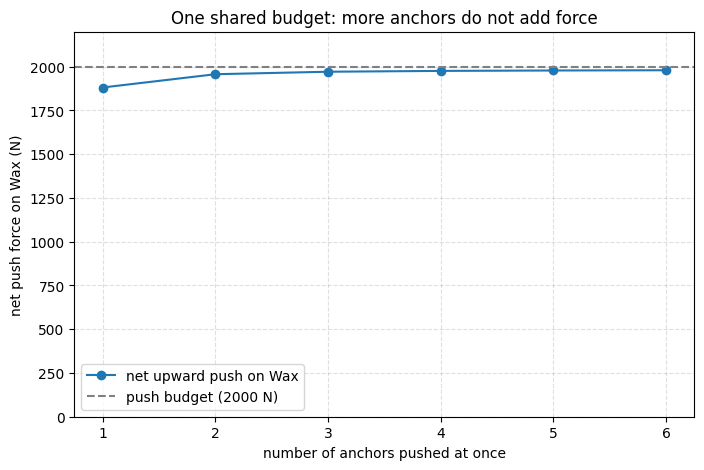

In [2]:
def net_push_force(anchor_count):
    world = World()
    wax = world.add_body(Body("wax", WAX_MASS_KG, (0, 1.0)))

    # Lay the anchors out in a short horizontal row just below Wax. With one
    # anchor we put it straight under him; with several we spread them evenly
    # across a 40 cm span centered under him. np.linspace(start, stop, count)
    # hands back "count" evenly spaced numbers from start to stop, so this is
    # the list of x positions (sideways offsets) for the row of anchors.
    if anchor_count > 1:
        anchor_x_positions = np.linspace(-0.2, 0.2, anchor_count)
    else:
        anchor_x_positions = [0.0]

    # Build one fixed anchor at each x position, all at the same low height.
    anchors = []
    for anchor_index, x_position in enumerate(anchor_x_positions):
        anchors.append(fixed_anchor(world, f"anchor{anchor_index}", (x_position, 0.05)))

    push = world.add_power(Steelpush(wax, anchors, PUSH_BUDGET_N))
    push.active = True
    world.step()  # advance one tick, before anything has had time to move

    # Recover the push force Wax felt. In one tick he gained some upward
    # velocity; mass times (velocity gained / tick length) is the net upward
    # force that produced it. That net already has gravity subtracted out, so
    # add gravity's downward pull back in to isolate the push by itself.
    upward_velocity_gained = wax.velocity[1]
    net_upward_force = WAX_MASS_KG * upward_velocity_gained / world.dt_seconds
    return net_upward_force + WAX_MASS_KG * GRAVITY_M_PER_S2


# Measure the net push for a growing cluster of anchors, one cluster size at a time.
anchor_counts = [1, 2, 3, 4, 5, 6]
net_forces = []
for count in anchor_counts:
    net_forces.append(net_push_force(count))

print(f"{'anchors':>7}  {'net push up (N)':>15}")
for count, force in zip(anchor_counts, net_forces):
    print(f"{count:7d}  {force:15.0f}")

plt.figure(figsize=(8, 5))
plt.plot(anchor_counts, net_forces, "o-", label="net upward push on Wax")
plt.axhline(PUSH_BUDGET_N, color="gray", linestyle="--",
            label="push budget (2000 N)")
plt.xlabel("number of anchors pushed at once")
plt.ylabel("net push force on Wax (N)")
plt.title("One shared budget: more anchors do not add force")
plt.ylim(0, 2200)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

One anchor delivers 1881 N - the 2000 N budget times its distance falloff.
Adding anchors fills the rest of the budget toward 2000 N and levels off:
six anchors give 1980 N, not six times anything. The launch saturates at
the Allomancer's strength no matter how many coins are in front of them.
(It settles a touch under 2000 because the spread-out anchors push at slight
angles, so their vertical components do not quite sum to the full budget.)

## Experiment B - why a tripod

Canon has Coinshots fly on a tripod of coins for stability. Our Wax is a
point mass and cannot rotate, so 'stability' here is about direction, not
balance: an anchor off to one side pushes you away from it - sideways, not
just up.

Paper prediction: a single off-center anchor shoves Wax sideways; a
symmetric pair cancels the sideways shove and leaves a clean vertical push;
a tripod (the pair plus a center anchor) does the same but lifts harder.

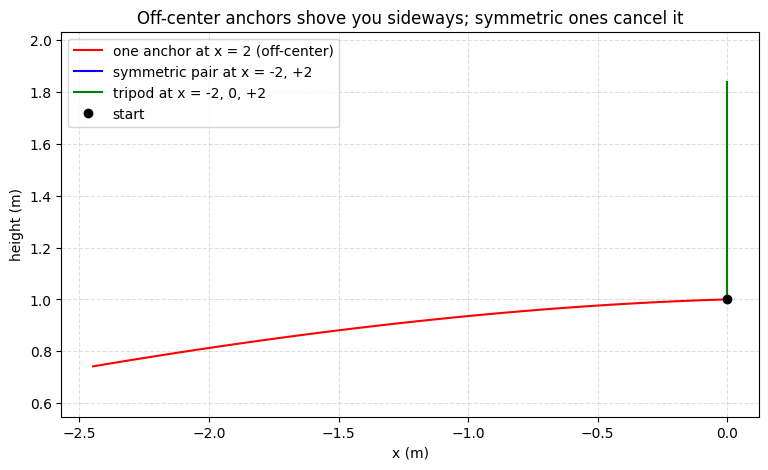

single off-center: Wax ends at x = -2.45 m (shoved away from the anchor)
symmetric pair:    Wax ends at x = +0.00 m (straight up)
tripod:            Wax ends at x = +0.00 m (straight up, higher lift)


In [3]:
def fly(anchor_positions, seconds=0.5):
    world = World()
    wax = world.add_body(Body("wax", WAX_MASS_KG, (0, 1.0)))

    # Place one fixed anchor at each requested position.
    anchors = []
    for anchor_index, position in enumerate(anchor_positions):
        anchors.append(fixed_anchor(world, f"anchor{anchor_index}", position))

    push = world.add_power(Steelpush(wax, anchors, PUSH_BUDGET_N))
    push.active = True
    world.run(seconds)

    # Pull Wax's recorded path out of the run: his sideways position (x) and
    # his height (y) at every tick, each turned into an array for plotting.
    path = world.history.body("wax")
    horizontal_path = np.array(path["x"])
    vertical_path = np.array(path["y"])
    return horizontal_path, vertical_path


plt.figure(figsize=(9, 5))

single_x, single_y = fly([(2.0, 0.05)])
plt.plot(single_x, single_y, "r-", label="one anchor at x = 2 (off-center)")

pair_x, pair_y = fly([(-2.0, 0.05), (2.0, 0.05)])
plt.plot(pair_x, pair_y, "b-", label="symmetric pair at x = -2, +2")

tripod_x, tripod_y = fly([(-2.0, 0.05), (0.0, 0.05), (2.0, 0.05)])
plt.plot(tripod_x, tripod_y, "g-", label="tripod at x = -2, 0, +2")

plt.plot(0, 1.0, "k.", markersize=12, label="start")
plt.xlabel("x (m)")
plt.ylabel("height (m)")
plt.title("Off-center anchors shove you sideways; symmetric ones cancel it")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.axis("equal")
plt.show()

print(f"single off-center: Wax ends at x = {single_x[-1]:+.2f} m (shoved away from the anchor)")
print(f"symmetric pair:    Wax ends at x = {pair_x[-1]:+.2f} m (straight up)")
print(f"tripod:            Wax ends at x = {tripod_x[-1]:+.2f} m (straight up, higher lift)")

Pushing one anchor off to the right throws Wax 2.45 m to the LEFT in half a
second - away from the anchor, exactly as a force pair must. A symmetric
pair cancels the sideways component to zero, and Wax rises straight up. The
tripod does the same and lifts higher, because its center anchor adds
vertical push while the outer two still cancel sideways. That is what the
canonical flying tripod becomes for a body that cannot rotate: symmetric
anchors convert a shove-off-to-the-side into a controllable straight-up
push.

## Findings

1. **The push is one shared budget.** Several anchors split the
   Allomancer's total strength, capped - never a multiple of a single push.
   One point-blank anchor already maxes it (1881 of 2000 N); six together
   reach 1980 N and level off. Non-canon modeling choice: canon is silent on
   how multi-target pushes divide (checked against Coppermind and 17th
   Shard); we cap the total budget, grounded in canon's 'push tracks your
   weight, force reflects onto you'.
2. **Symmetric anchors cancel the sideways shove.** A lone off-center
   anchor pushes you away from it (Wax thrown 2.45 m sideways); a balanced
   set leaves a clean vertical push. This is what the canonical flying
   tripod becomes for a body that cannot rotate - the tripod's value shows
   up as directional control, not balance.
3. **Implication, not separately run:** a loose coin drifting into your
   push field claims a share of the budget while it is in range, weakening
   your launch until it flies clear. The budget is shared with whatever
   metal is in front of you, wanted or not - a real cost of the shared-pool
   model, worth a future experiment.
4. **Single pushes are unchanged.** The cap never binds when there is only
   one target, so a lone push delivers exactly what it did before this
   notebook - notebook 02's single-coin launch is untouched. The shared
   budget only ever changes what happens with two or more targets at once.

Open canon question this raised: whether the push really is a shared budget
is exactly the kind of thing Brandon's verbose Coinshot battles could
settle, if the series text were searchable. Filed for the project's
eventual canon-research layer.

Next in the steel arc: notebook 15 - the Coinshot hover (why a steady push
oscillates, and what actually damps it).